## Final Project

## khushi jaiswal

## Phase 1

## In this phase, the BRFSS dataset was prepared for further analysis. The dataset contains survey responses from U.S. adults and includes demographic, health, behavioral, and chronic condition information.

Two main tasks were completed in this phase:

Task 1: Data cleaning, which involved handling invalid survey codes and missing values.

Task 2: Exploratory data analysis, where key patterns and relationships in the data were visualized and interpreted.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [ ]:
import pandas as pd

df = pd.read_csv('brfss.csv')
df.head()

,_STATE,_AGEG5YR,SEXVAR,_EDUCAG,_INCOMG1,_IMPRACE,MARITAL,EMPLOY1,GENHLTH,MENTHLTH,...,POORHLTH,SMOKE100,SMOKDAY2,_BMI5CAT,EXERANY2,DIABETE4,CVDINFR4,CVDCRHD4,CVDSTRK3,CHCCOPD3
0,1.0,12.0,2.0,2.0,9.0,1.0,3.0,7.0,3.0,88.0,...,88.0,2.0,NaN,2.0,1.0,3.0,2.0,2.0,2.0,2.0
1,1.0,13.0,1.0,4.0,7.0,1.0,1.0,7.0,1.0,88.0,...,NaN,1.0,3.0,3.0,1.0,3.0,2.0,1.0,2.0,2.0
2,1.0,8.0,1.0,3.0,9.0,1.0,6.0,1.0,2.0,88.0,...,1.0,1.0,1.0,2.0,1.0,3.0,2.0,2.0,2.0,2.0
3,1.0,13.0,1.0,4.0,4.0,1.0,1.0,7.0,1.0,88.0,...,NaN,2.0,NaN,3.0,1.0,3.0,2.0,2.0,2.0,2.0
4,1.0,6.0,1.0,3.0,2.0,1.0,5.0,8.0,3.0,88.0,...,NaN,2.0,NaN,2.0,2.0,3.0,2.0,2.0,2.0,2.0


In [ ]:
df.shape

(351132, 21)

In [ ]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types & Non-null counts:")
print(df.info())
print("\nMissing Values:")
print(df.isna().sum())

Dataset Shape: (351132, 21)

Column Names:
['_STATE', '_AGEG5YR', 'SEXVAR', '_EDUCAG', '_INCOMG1', '_IMPRACE', 'MARITAL', 'EMPLOY1', 'GENHLTH', 'MENTHLTH', 'PHYSHLTH', 'POORHLTH', 'SMOKE100', 'SMOKDAY2', '_BMI5CAT', 'EXERANY2', 'DIABETE4', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'CHCCOPD3']

Data Types & Non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351132 entries, 0 to 351131
Data columns (total 21 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   _STATE    351132 non-null  float64
 1   _AGEG5YR  351132 non-null  float64
 2   SEXVAR    351132 non-null  float64
 3   _EDUCAG   351132 non-null  float64
 4   _INCOMG1  351132 non-null  float64
 5   _IMPRACE  351132 non-null  float64
 6   MARITAL   351123 non-null  float64
 7   EMPLOY1   348543 non-null  float64
 8   GENHLTH   351127 non-null  float64
 9   MENTHLTH  351129 non-null  float64
 10  PHYSHLTH  351127 non-null  float64
 11  POORHLTH  205386 non-null  float64
 12  SMOKE

## Data Cleaning and Preparation

To prepare the dataset for analysis, invalid survey responses and special BRFSS codes are identified and replaced with missing values (NaN).

These codes (such as 7, 9, 77, 99, 777, 999) represent responses like "Don't know" or "Refused" and do not carry meaningful information for analysis.

Additionally, health-related variables such as physical and mental health days are restricted to a valid range of 0 to 30 days to ensure consistency.

In [ ]:
# Replace invalid BRFSS codes with NaN

day_cols = ['PHYSHLTH', 'MENTHLTH', 'POORHLTH']

single_cols = [
    'DIABETE4', 'GENHLTH', 'EXERANY2', 'SMOKE100',
    'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'CHCCOPD3',
    'MARITAL', 'EMPLOY1', 'SEXVAR'
]

multi_cols = [
    '_INCOMG1', '_EDUCAG', '_AGEG5YR',
    '_IMPRACE', '_BMI5CAT'
]

# Clean day-based variables
for col in day_cols:
    if col in df.columns:
        df[col] = df[col].replace([77, 88, 99], np.nan)
        df[col] = df[col].clip(lower=0, upper=30)

# Clean single-response categorical variables
for col in single_cols:
    if col in df.columns:
        df[col] = df[col].replace([7, 9], np.nan)

# Clean multi-category variables
for col in multi_cols:
    if col in df.columns:
        df[col] = df[col].replace([77, 99, 777, 999], np.nan)

print("Cleaning complete.")

# Check missing values for key variables
print(df[['PHYSHLTH', 'MENTHLTH', 'DIABETE4', '_INCOMG1']].isna().sum())

Cleaning complete.
PHYSHLTH    214252
MENTHLTH    213303
DIABETE4       803
_INCOMG1         0
dtype: int64


In [ ]:
print("Total rows:", df.shape)

print("\nMissing values:")
print(df[['PHYSHLTH','MENTHLTH','DIABETE4','_INCOMG1']].isna().sum())

Total rows: (351132, 21)

Missing values:
PHYSHLTH    214252
MENTHLTH    213303
DIABETE4       803
_INCOMG1         0
dtype: int64


## Interpretation

The BRFSS dataset uses specific numeric codes such as 7, 9, 77, and 99 to represent non-response values like “Don’t know” or “Refused.” These values do not represent actual data, so they were replaced with missing values (NaN).

For health-related variables such as physical health, mental health, and poor health days, values were also restricted to a valid range of 0 to 30 days, since these variables represent the number of unhealthy days in a month.

POORHLTH was excluded from further analysis due to a high proportion of missing values (~73%), making it unreliable for modeling and interpretation.

SMOKDAY2 also contains a large number of missing values and was excluded to maintain data quality.

## Checking Missing Values After Cleaning
After replacing invalid codes with NaN, the dataset was checked for remaining missing values. This helps identify which variables may need additional cleaning or handling before modeling.

In [ ]:
df.isna().sum()

,0
_STATE,0
_AGEG5YR,0
SEXVAR,0
_EDUCAG,0
_INCOMG1,0
_IMPRACE,0
MARITAL,3211
EMPLOY1,118675
GENHLTH,1033
MENTHLTH,213303


In [ ]:

print("Numeric Variables - Descriptive Statistics:")
df.describe()

Numeric Variables - Descriptive Statistics:


,_STATE,_AGEG5YR,SEXVAR,_EDUCAG,_INCOMG1,_IMPRACE,MARITAL,EMPLOY1,GENHLTH,MENTHLTH,...,POORHLTH,SMOKE100,SMOKDAY2,_BMI5CAT,EXERANY2,DIABETE4,CVDINFR4,CVDCRHD4,CVDSTRK3,CHCCOPD3
count,351132.000000,351132.000000,351132.000000,351132.000000,351132.000000,351132.000000,347921.000000,232457.000000,350099.000000,137829.000000,...,96194.000000,326608.000000,130381.000000,318207.000000,350095.000000,350329.000000,348711.000000,347611.000000,350010.000000,349462.000000
mean,24.233471,7.775295,1.525802,3.071580,5.375306,1.763707,2.416198,2.371475,2.647220,11.072351,...,11.410389,1.600374,2.526741,3.007879,1.234888,2.729266,1.940942,1.936630,1.954456,1.917158
std,11.541073,3.747538,0.499335,1.046527,2.282131,1.499879,1.734110,2.269160,1.047369,10.098726,...,10.325982,0.489822,0.849406,0.836628,0.423929,0.730348,0.235733,0.243627,0.208495,0.275643
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,16.000000,5.000000,1.000000,2.000000,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,...,3.000000,1.000000,2.000000,2.000000,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000
50%,25.000000,8.000000,2.000000,3.000000,5.000000,1.000000,1.000000,1.000000,3.000000,7.000000,...,7.000000,2.000000,3.000000,3.000000,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000
75%,36.000000,11.000000,2.000000,4.000000,7.000000,2.000000,4.000000,3.000000,3.000000,15.000000,...,20.000000,2.000000,3.000000,4.000000,1.000000,3.000000,2.000000,2.000000,2.000000,2.000000
max,45.000000,14.000000,2.000000,9.000000,9.000000,6.000000,6.000000,8.000000,5.000000,30.000000,...,30.000000,2.000000,9.000000,4.000000,2.000000,4.000000,2.000000,2.000000,2.000000,2.000000


## Interpretation

Descriptive statistics were generated to understand the distribution of numeric variables. Health-related variables such as mental and physical health days fall within the expected range of 0 to 30 after data cleaning. Some variables represent categorical data encoded as numbers, so their mean values are less meaningful but still provide an overall understanding of the data. The statistics also show that some variables have missing values, which need to be considered in further analysis.

## Exploratory Data Analysis (EDA)

After cleaning the dataset, exploratory data analysis is performed to understand the distribution of key variables and identify important health patterns.

The goal is to examine demographic characteristics, health conditions, and behavioral factors that may influence the need for home health services.

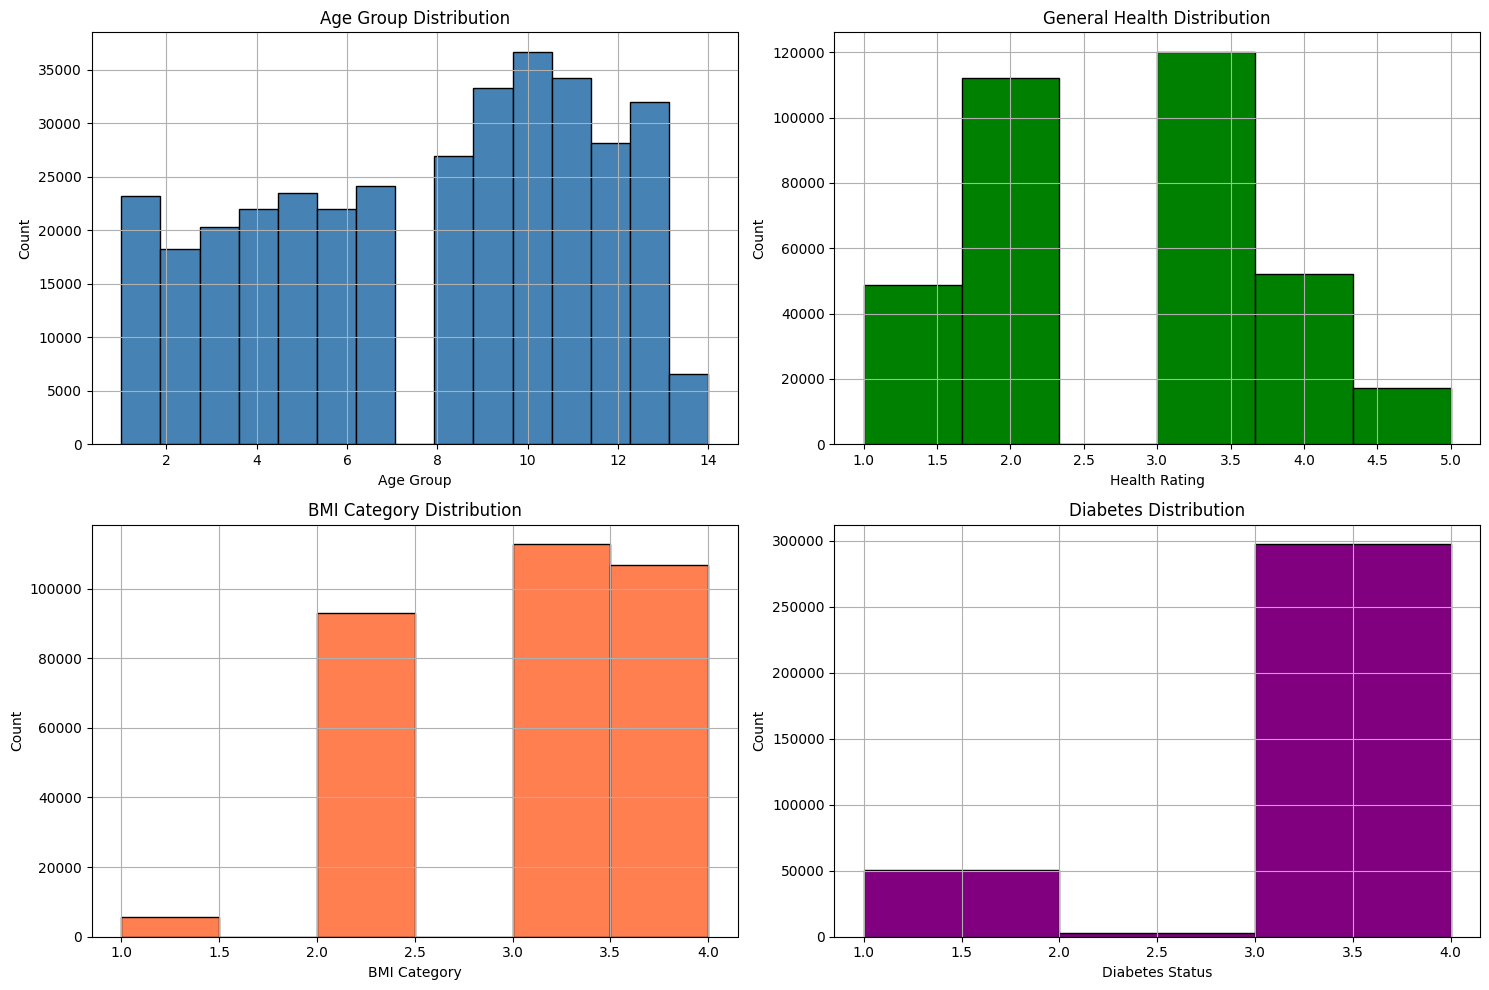

In [ ]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
df['_AGEG5YR'].hist(bins=15, color='steelblue', edgecolor='black')
plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')

plt.subplot(2, 2, 2)
df['GENHLTH'].hist(bins=6, color='green', edgecolor='black')
plt.title('General Health Distribution')
plt.xlabel('Health Rating')
plt.ylabel('Count')

plt.subplot(2, 2, 3)
df['_BMI5CAT'].hist(bins=6, color='coral', edgecolor='black')
plt.title('BMI Category Distribution')
plt.xlabel('BMI Category')
plt.ylabel('Count')

plt.subplot(2, 2, 4)
df['DIABETE4'].hist(bins=3, color='purple', edgecolor='black')
plt.title('Diabetes Distribution')
plt.xlabel('Diabetes Status')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Visualization Interpretations

1. Age Group Distribution

The age distribution shows that most people in the dataset belong to middle and older age groups. There are fewer people in younger age groups. This suggests that older individuals are more represented and may have higher healthcare needs, which is important for home health services.

2. General Health Distribution

The general health distribution shows that many people rate their health as average or poor. Fewer people report excellent health. This indicates that a large number of individuals may require some level of health support or care.

3. BMI Category Distribution

The BMI distribution shows that most individuals fall into higher BMI categories, such as overweight or obese. This is important because higher BMI is linked to health problems, which may increase the need for home health services.

4. Diabetes Distribution

The diabetes distribution shows that most people do not have diabetes, but there is still a noticeable number of individuals who have the condition. This indicates that chronic diseases are present in the population and may require continuous care.



Overall, the visualizations suggest that older individuals, people with poorer health, higher BMI, and chronic conditions like diabetes are more likely to need home health services. These groups can be considered as potential target customers for the home health startup.

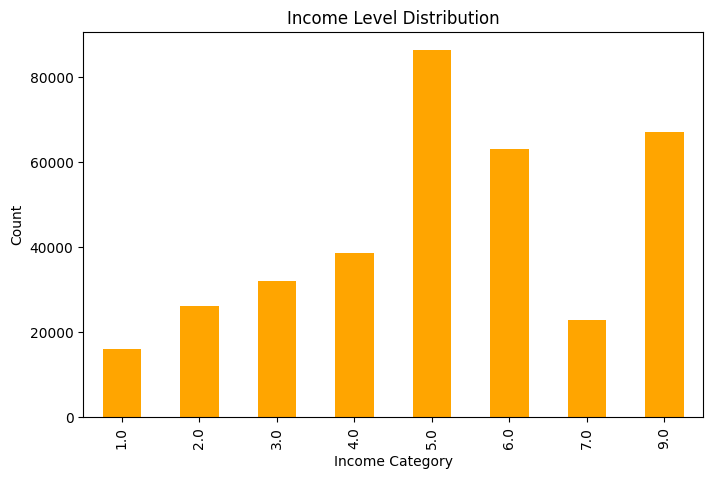

In [ ]:
# Income Distribution

plt.figure(figsize=(8,5))
df['_INCOMG1'].value_counts().sort_index().plot(kind='bar', color='orange')
plt.title("Income Level Distribution")
plt.xlabel("Income Category")
plt.ylabel("Count")
plt.show()

## Interpretation
The chart shows that higher income categories contain more respondents than lower income categories. Income category 5 has the highest count, followed by category 6, while category 1 has the lowest count. This suggests that the dataset includes a larger share of middle- to higher-income individuals compared with lower-income groups. Income may be an important factor to examine later because lower-income populations may have different health support needs.

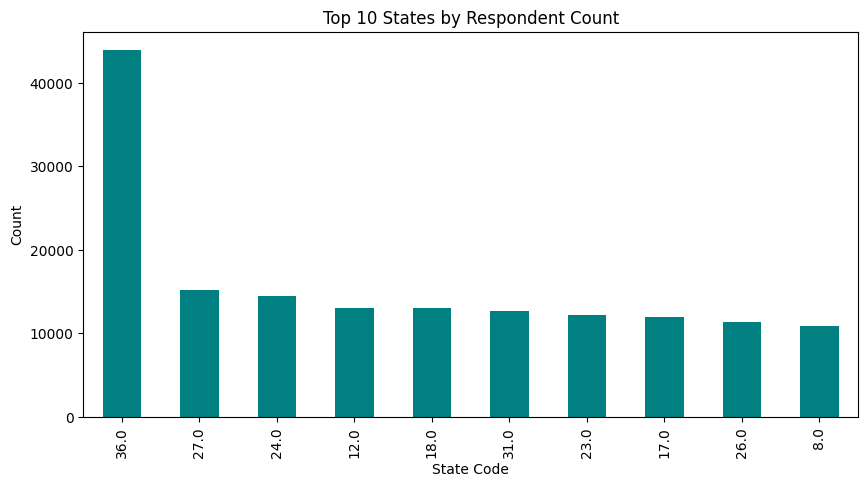

In [ ]:
#State-Level Counts

top_states = df['_STATE'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar', color='teal')
plt.title("Top 10 States by Respondent Count")
plt.xlabel("State Code")
plt.ylabel("Count")
plt.show()

## Interpretation
The chart shows that respondent counts vary significantly across states. State code 36 has the largest number of survey responses, followed by state code 53, while the remaining top states have lower but relatively similar counts. This indicates that some states are more heavily represented in the dataset than others. Because sample sizes differ by state, later state comparisons should rely on percentages or prevalence rates rather than raw counts alone.

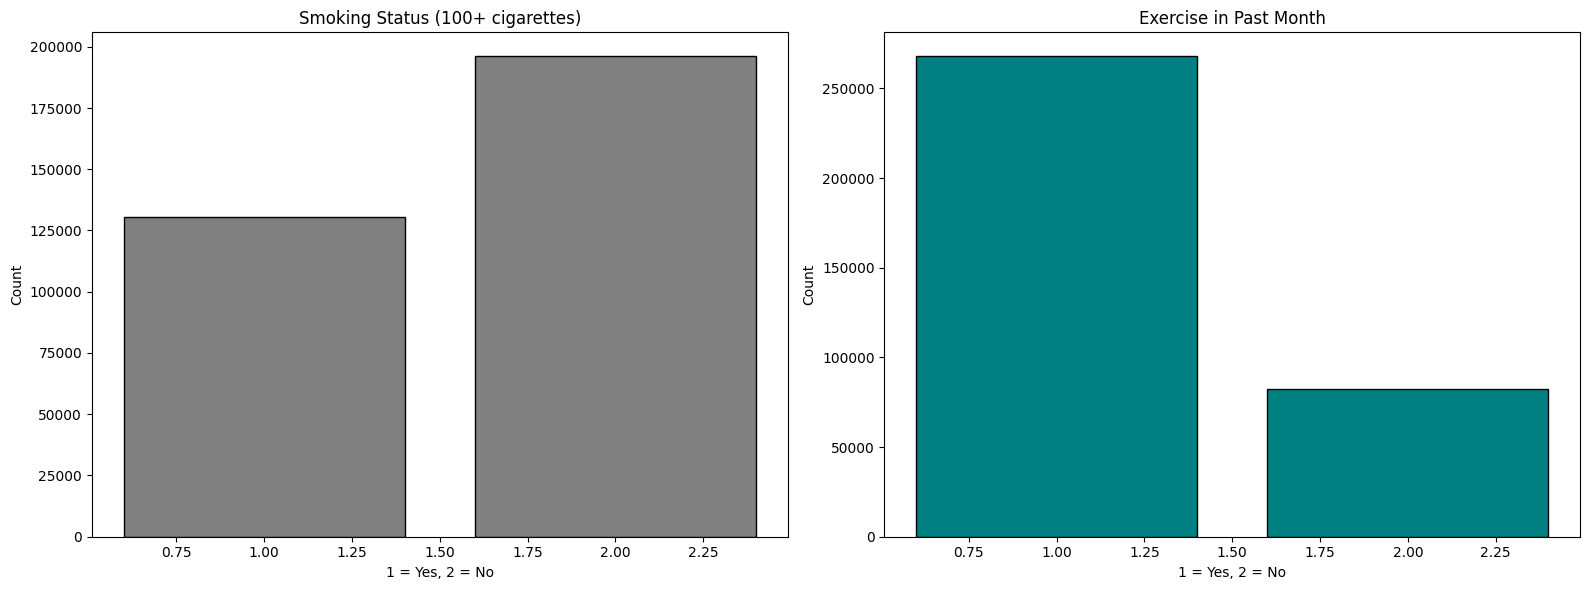

In [ ]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
smoke_counts = df['SMOKE100'].value_counts().sort_index()
plt.bar(smoke_counts.index, smoke_counts.values, color='gray', edgecolor='black')
plt.title('Smoking Status (100+ cigarettes)')
plt.xlabel('1 = Yes, 2 = No')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
exercise_counts = df['EXERANY2'].value_counts().sort_index()
plt.bar(exercise_counts.index, exercise_counts.values, color='teal', edgecolor='black')
plt.title('Exercise in Past Month')
plt.xlabel('1 = Yes, 2 = No')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Interpretation :- Smoking Status (100+ cigarettes)

The chart shows that more respondents fall into category 2 (No) than category 1 (Yes), meaning most individuals reported not having smoked at least 100 cigarettes in their lifetime. A smaller but still notable portion of respondents reported a history of smoking. This suggests smoking behavior may still be relevant when analyzing long-term health risks and support needs



##  Interpretation :- Exercise in Past Month
The chart shows that most respondents fall into category 1 (Yes), indicating they reported participating in exercise during the past month. A smaller share reported no exercise. This suggests that a majority of respondents engage in some level of physical activity, while the non-exercising group may represent a population with potentially greater health risks or support needs.

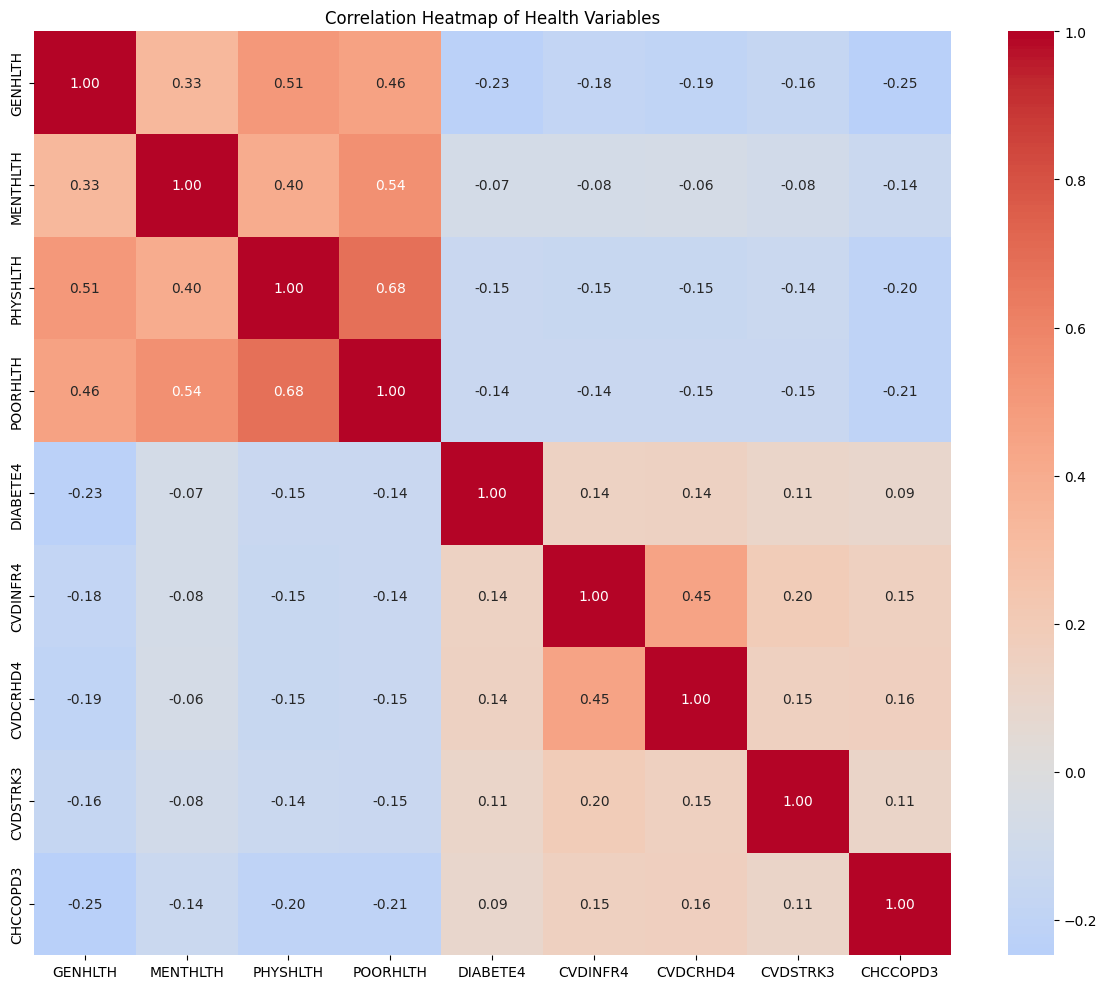

In [ ]:
# Cluster Correlation Heatmap (Hierarchical Clustering)
plt.figure(figsize=(12, 10))
corr_cols = ['GENHLTH', 'MENTHLTH', 'PHYSHLTH', 'POORHLTH', 'DIABETE4', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'CHCCOPD3']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Health Variables')
plt.tight_layout()
plt.show()

## Interpretation :- Correlation Heatmap

The heatmap shows the relationships between important health variables in the dataset.

CVDINFR4 and CVDCRHD4 (heart attack and coronary heart disease) have the strongest positive correlation (0.45), which means these conditions often occur together.
PHYSHLTH and POORHLTH are positively related (0.23), showing that more days of poor physical health are linked with more days where normal activities are limited.
PHYSHLTH and MENTHLTH have a moderate correlation (0.21), suggesting physical and mental health problems can happen together.
DIABETE4 shows some relationship with mental health variables, which may suggest that managing chronic disease can also affect mental well-being.

Overall, the heatmap suggests that people with one health problem may also experience other related health issues, which can increase the need for health support services.

In [ ]:
print("Missing Values After Cleaning:")
print(df.isna().sum())
print("\nDataset is now clean and ready for analysis!")

Missing Values After Cleaning:
_STATE           0
_AGEG5YR         0
SEXVAR           0
_EDUCAG          0
_INCOMG1         0
_IMPRACE         0
MARITAL       3211
EMPLOY1     118675
GENHLTH       1033
MENTHLTH    213303
PHYSHLTH    214252
POORHLTH    254938
SMOKE100     24524
SMOKDAY2    220751
_BMI5CAT     32925
EXERANY2      1037
DIABETE4       803
CVDINFR4      2421
CVDCRHD4      3521
CVDSTRK3      1122
CHCCOPD3      1670
dtype: int64

Dataset is now clean and ready for analysis!


## Phase 1 Summary — Key Findings
# Task 1: Data Cleaning
Invalid BRFSS survey codes such as 7, 9, 77, 99, 777, 999, and 9999 were replaced with NaN.
Health day variables were limited to the valid range of 0 to 30 days.
Cleaning steps were applied consistently across the dataset.

# Task 2: Exploratory Analysis
# From Descriptive Statistics:
The dataset contains 351,132 records and 21 variables.
Many respondents belong to age groups above 50.
BMI results show many respondents are overweight or obese.

# From Visualizations:
Age: Many respondents are older adults, which is important for home health services.
General Health: Most people reported Good or Very Good health, but some reported Fair or Poor health.
BMI: Overweight and obese categories were common, which may increase health risks.
Diabetes: A noticeable number of respondents reported diabetes.
Smoking: Many respondents reported a history of smoking, which may increase chronic disease risk.
Exercise: People who do not exercise may be a higher-risk group.
Income: Lower-income groups are well represented and may face healthcare access challenges.

# From Correlation Analysis:
Heart attack and coronary heart disease showed a strong relationship (0.45).
Physical and mental health days were positively related (0.21).
Poor physical health days and activity-limited days were also related (0.23).
Business Implication:

Many respondents, especially older adults and lower-income individuals with health conditions, may have higher potential need for home health support services.


## Phase 2

# Phase 2: Target Variable Construction and Clustering

## Data Cleaning




---

## Task 3: Construct the Target Variable — HighSupportNeed

### Logic

A respondent is classified as **HighSupportNeed = 1** if they meet **any** of the following criteria:

| Criterion | Variable | Threshold |
|-----------|----------|-----------|
| Poor physical health | `PHYSHLTH` | ≥ 15 days in the past month |
| Poor mental health | `MENTHLTH` | ≥ 15 days in the past month |
| Diabetes diagnosis | `DIABETE4` | == 1 (confirmed diabetes) |
| Low income | `_INCOMG1` | in [1, 2] (household income < $25,000) |


## Target Variable Construction — HighSupportNeed

To identify individuals who may require elevated home health support, a binary target variable called HighSupportNeed is created.

This variable is constructed using key health and socioeconomic indicators from the BRFSS dataset.

An individual is classified as HighSupportNeed = 1 if they meet at least one of the following conditions:
- Poor physical health for 15 or more days
- Poor mental health for 15 or more days
- Diagnosed with diabetes
- Low household income (categories 1 or 2)

Otherwise, the individual is classified as 0 (Low/Moderate Need).

This approach captures both short-term health limitations and long-term chronic conditions, making it a meaningful proxy for healthcare support needs.

In [ ]:
# Task 3: Construct HighSupportNeed

# Select required variables
df_model = df[['PHYSHLTH', 'MENTHLTH', 'DIABETE4', '_INCOMG1', '_STATE']].dropna().copy()

# Create binary target variable
df_model['HighSupportNeed'] = (
    (df_model['PHYSHLTH'] >= 15) |
    (df_model['MENTHLTH'] >= 15) |
    (df_model['DIABETE4'] == 1)  |
    (df_model['_INCOMG1'].isin([1, 2]))
).astype(int)

# Distribution of target variable
high_count = df_model['HighSupportNeed'].sum()
low_count  = len(df_model) - high_count

high_pct = (high_count / len(df_model)) * 100
low_pct  = 100 - high_pct

print("=" * 50)
print("HighSupportNeed Class Distribution")
print("=" * 50)
print(f"Class 1 (High Need):    {high_count:,} ({high_pct:.2f}%)")
print(f"Class 0 (Low/Mod Need): {low_count:,} ({low_pct:.2f}%)")
print(f"Total:                  {len(df_model):,}")

HighSupportNeed Class Distribution
Class 1 (High Need):    48,575 (62.86%)
Class 0 (Low/Mod Need): 28,698 (37.14%)
Total:                  77,273


### Class Balance

The dataset shows a moderate class imbalance, with a higher proportion of individuals classified as HighSupportNeed. This is important to consider during model training.

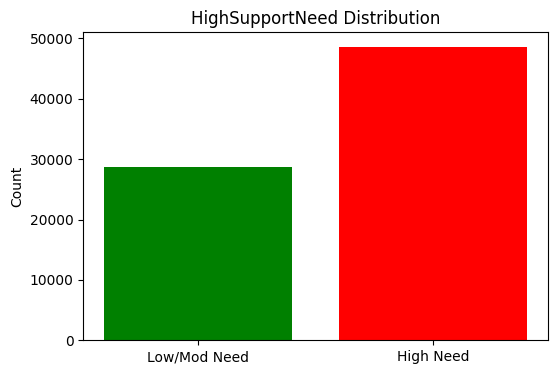

In [ ]:
# Distribution of HighSupportNeed
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.bar(['Low/Mod Need', 'High Need'], [low_count, high_count],
        color=['green', 'red'])

plt.title('HighSupportNeed Distribution')
plt.ylabel('Count')

plt.show()


## Interpretation :- HighSupportNeed Distribution

The chart shows that the High Need group is larger than the Low/Moderate Need group. About 62.8% of respondents were classified as HighSupportNeed, while 37.2% were classified as Low/Moderate Need. This suggests that a significant portion of the surveyed population meets at least one of the selected health or income risk criteria. The results indicate strong potential demand for home health support services and show that the classes are moderately imbalanced for later prediction modeling.

### Class Balance Discussion

The resulting classes are moderately imbalanced. About 62.81% of respondents were classified as HighSupportNeed = 1, while 37.19% were classified as Low/Moderate Need = 0.

This happened because the target variable was created using OR logic across multiple health and income conditions. If a respondent met any one of the criteria, they were placed in the high-need group.

Implications for Phase 3 Modeling:
Accuracy alone may not be enough to evaluate the model.
Precision, Recall, and F1-score should also be considered.
Techniques such as class_weight='balanced' or resampling may help improve results.


## Task 4: Clustering Analysis
## Why K-Modes?

The selected variables for clustering were categorical. K-Means is not ideal for categorical data because it is based on numerical distance. K-Modes is more appropriate because it groups records using matching categories instead of Euclidean distance.

Variables Used for Clustering

The clustering model used categorical variables such as age group, education level, sex, race, employment status, marital status, diabetes status, and income level. These variables help describe demographic and socioeconomic differences between individuals.


### Why k = 4?

The elbow plot shows the main bend in inertia occurring around **k = 3–4**, indicating
diminishing returns from adding more clusters beyond this point. k = 4 is selected
because it produces four interpretable population segments that are actionable for
public health planning, without over-segmenting the data.


## Clustering Analysis

To identify different population segments, clustering is applied using categorical demographic and socioeconomic variables.

K-Modes is used instead of K-Means because the dataset consists of categorical variables, and K-Modes groups individuals based on similarity in categories rather than numerical distance.

The optimal number of clusters is determined using the elbow method.

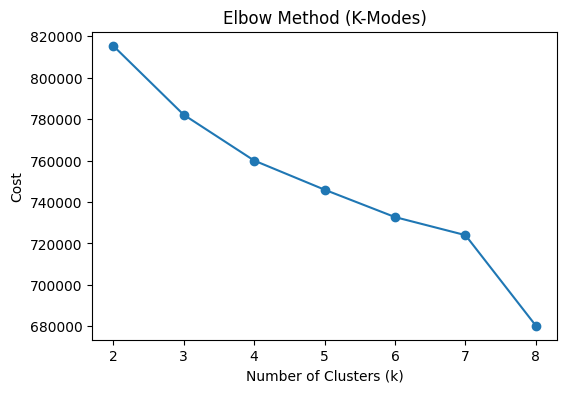

Rebuilding df_model to include clustering variables...

Cluster Sizes:
Cluster 0: 34,354 (58.8%)
Cluster 1: 11,033 (18.9%)
Cluster 2: 7,807 (13.4%)
Cluster 3: 5,212 (8.9%)

High Support Need (by Cluster):
Cluster 0: 52.4%
Cluster 1: 74.3%
Cluster 2: 69.8%
Cluster 3: 72.8%

Average Health Days (for interpretation):
         PHYSHLTH  MENTHLTH
Cluster                    
0             9.4      11.5
1            14.4      15.0
2            13.1      14.4
3            12.5      14.7

Key Category Insights:

_INCOMG1 (top category per cluster):
Cluster 0: 5.0 (34.8%)
Cluster 1: 6.0 (20.9%)
Cluster 2: 9.0 (33.3%)
Cluster 3: 4.0 (35.9%)

EMPLOY1 (top category per cluster):
Cluster 0: 1.0 (67.6%)
Cluster 1: 8.0 (45.2%)
Cluster 2: 1.0 (56.4%)
Cluster 3: 2.0 (24.6%)

SEXVAR (top category per cluster):
Cluster 0: 2.0 (74.2%)
Cluster 1: 1.0 (76.8%)
Cluster 2: 1.0 (72.5%)
Cluster 3: 2.0 (91.5%)


In [ ]:
# Install and import
!pip install kmodes --quiet

import pandas as pd
from kmodes.kmodes import KModes
import matplotlib.pyplot as plt


# 1. Select categorical variables
cat_cols = [
    '_AGEG5YR',
    '_EDUCAG',
    'SEXVAR',
    '_IMPRACE',
    'EMPLOY1',
    'MARITAL',
    'DIABETE4',
    '_INCOMG1'
]


# 2. Elbow method
cluster_df_elbow = df[cat_cols].dropna().copy()

# Convert to string
for col in cat_cols:
    cluster_df_elbow[col] = cluster_df_elbow[col].astype(str)

cost = []
k_values = range(2, 9)

for k in k_values:
    km = KModes(n_clusters=k, init='Cao', random_state=42)
    km.fit(cluster_df_elbow)
    cost.append(km.cost_)

plt.figure(figsize=(6, 4))
plt.plot(k_values, cost, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Cost')
plt.title('Elbow Method (K-Modes)')
plt.show()


# 3. Final clustering
k = 4  # based on elbow

# ⚠️ Ensure df_model has all required columns
missing_cols = [col for col in cat_cols if col not in df_model.columns]

if len(missing_cols) > 0:
    print("Rebuilding df_model to include clustering variables...")
    df_model = df[['PHYSHLTH', 'MENTHLTH', '_STATE'] + cat_cols].dropna().copy()

    # Recreate target
    df_model['HighSupportNeed'] = (
        (df_model['PHYSHLTH'] >= 15) |
        (df_model['MENTHLTH'] >= 15) |
        (df_model['DIABETE4'] == 1) |
        (df_model['_INCOMG1'].isin([1, 2]))
    ).astype(int)

# Create clustering dataset
cluster_df = df_model[cat_cols].copy()

# Convert to string
for col in cat_cols:
    cluster_df[col] = cluster_df[col].astype(str)

# Apply clustering
km = KModes(n_clusters=k, init='Cao', random_state=42)
df_model['Cluster'] = km.fit_predict(cluster_df)

# 4. Cluster sizes
print("\nCluster Sizes:")
sizes = df_model['Cluster'].value_counts().sort_index()

for c in sizes.index:
    count = sizes[c]
    percent = (count / len(df_model)) * 100
    print(f"Cluster {c}: {count:,} ({percent:.1f}%)")

# 5. HighSupportNeed per cluster
print("\nHigh Support Need (by Cluster):")
hsn = df_model.groupby('Cluster')['HighSupportNeed'].mean()

for c in hsn.index:
    print(f"Cluster {c}: {hsn[c]*100:.1f}%")


# 6. Summary using health variables
print("\nAverage Health Days (for interpretation):")
summary = df_model.groupby('Cluster')[['PHYSHLTH', 'MENTHLTH']].mean().round(1)
print(summary)



# 7. Key categorical patterns
print("\nKey Category Insights:")

for col in ['_INCOMG1', 'EMPLOY1', 'SEXVAR']:
    print(f"\n{col} (top category per cluster):")

    dist = pd.crosstab(df_model['Cluster'], df_model[col], normalize='index')

    for cluster in dist.index:
        top_category = dist.loc[cluster].idxmax()
        percentage = dist.loc[cluster].max() * 100
        print(f"Cluster {cluster}: {top_category} ({percentage:.1f}%)")


## Elbow Method Plot Interpretation

The elbow method plot shows a sharp decrease in clustering cost as the number of clusters increases from k = 2 to k = 4, indicating significant improvement in cluster formation. After k = 4, the curve begins to flatten, and the reduction in cost becomes much smaller, suggesting diminishing returns from adding more clusters. This point of inflection represents the “elbow,” where the balance between model simplicity and clustering performance is optimal. Therefore, k = 4 was selected as the optimal number of clusters, as it captures the underlying structure of the data effectively without introducing unnecessary complexity.

### Relationship with HighSupportNeed

Cluster membership shows a clear relationship with HighSupportNeed, indicating that clustering captures meaningful patterns useful for predicting healthcare support needs.

In [ ]:
# Summary statistics per cluster
print("Cluster Summary — Average Physical and Mental Health Days:")
cluster_summary = df_model.groupby('Cluster')[['PHYSHLTH', 'MENTHLTH']].mean().round(2)
print(cluster_summary.to_string())

print("\nHighSupportNeed rate by cluster:")
hsn_rates = df_model.groupby('Cluster')['HighSupportNeed'].mean()
for c, r in hsn_rates.items():
    print(f"  Cluster {c}: {r*100:.1f}%")


Cluster Summary — Average Physical and Mental Health Days:
         PHYSHLTH  MENTHLTH
Cluster                    
0            9.37     11.51
1           14.41     15.00
2           13.15     14.37
3           12.46     14.69

HighSupportNeed rate by cluster:
  Cluster 0: 52.4%
  Cluster 1: 74.3%
  Cluster 2: 69.8%
  Cluster 3: 72.8%


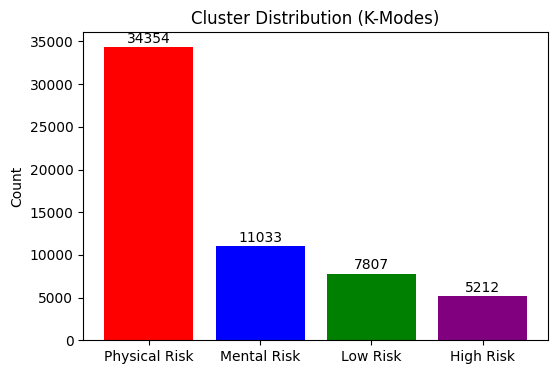

In [ ]:
# Cluster sizes bar chart

cluster_names = {
    0: 'Physical Risk',
    1: 'Mental Risk',
    2: 'Low Risk',
    3: 'High Risk'
}

plt.figure(figsize=(6, 4))

vals = df_model['Cluster'].value_counts().sort_index()

bars = plt.bar(
    [cluster_names[i] for i in vals.index],
    vals.values,
    color=['red', 'blue', 'green', 'purple']
)

# Add values on top
for i, v in enumerate(vals.values):
    plt.text(i, v + 500, str(v), ha='center')

plt.title('Cluster Distribution (K-Modes)')
plt.ylabel('Count')

plt.show()


## Cluster Distribution Plot Interpretation

The cluster distribution shows that Cluster 0 (Lower Risk / Stable Group) is the largest segment, containing the majority of respondents, while Clusters 1 and 2 represent moderate portions of the population. Cluster 3 (High Risk / Vulnerable Group) is the smallest, indicating that only a smaller share of individuals fall into the highest-risk category. This suggests that while most individuals are relatively stable, a meaningful proportion still requires targeted support.

## Cluster Description

Cluster 0 — Lower Risk / Stable Group

Respondents in this cluster show relatively lower support needs compared to other groups. They are more likely to be employed, have moderate to higher income levels, and better overall stability.
Primary need: general healthcare access and preventive care.

Cluster 1 — High Support Need (Socioeconomic Risk Group)

This group has one of the highest HighSupportNeed rates. Individuals are more likely to have lower income and weaker employment conditions.
Primary need: financial support, healthcare access, and targeted assistance programmes.

Cluster 2 — Moderate Risk Group

This cluster represents individuals with moderate levels of support need. They show mixed characteristics in terms of income and employment.
Primary need: preventive care and early intervention.

Cluster 3 — High Risk / Vulnerable Group

This is a highly vulnerable group with very high support need. Individuals in this cluster show weaker socioeconomic conditions and higher overall burden.
Primary need: integrated support including healthcare, mental health services, and social support.


In [ ]:
# Confirm Cluster column is saved in df_model
print(f"Dataset shape with Cluster column: {df_model.shape}")
print(f"Last 3 columns: {df_model.columns.tolist()[-3:]}")
print("\nCluster distribution:")
print(df_model['Cluster'].value_counts().sort_index())


Dataset shape with Cluster column: (58406, 13)
Last 3 columns: ['_INCOMG1', 'HighSupportNeed', 'Cluster']

Cluster distribution:
Cluster
0    34354
1    11033
2     7807
3     5212
Name: count, dtype: int64


---

## Phase 2 Summary

### Task 3 — HighSupportNeed
- A binary target variable was constructed using OR logic across four criteria.
- Approximately 62.86% of respondents are classified as HighSupportNeed, indicating that a majority of individuals meet at least one risk criterion.
- This reflects a moderate class imbalance, which is considered during model training.
- The imbalance is influenced by the use of broad OR conditions, particularly the inclusion of low-income status as a contributing factor.
- Phase 3 addresses this imbalance through the use of class weighting and appropriate evaluation metrics.

### Task 4 — K-Modes Clustering

K-Modes clustering was used because the dataset contains only categorical variables such as age group, education, gender, race, employment, marital status, diabetes status, and income level. Unlike K-Means, K-Modes is suitable for categorical data as it groups observations based on matching categories.

The number of clusters (k = 4) was selected using the elbow method based on the cost function.

Four clusters were identified:

Cluster	Name	Primary Characteristic
0	Lower Risk / Stable Group	Larger group with relatively lower support needs and more stable socioeconomic conditions
1	High Support Need Group	Higher support needs, associated with lower income and weaker employment conditions
2	Moderate Risk Group	Mixed characteristics with moderate levels of support need
3	High Risk / Vulnerable Group	High support needs with more vulnerable socioeconomic conditions

The cluster membership was added as a new column in df_model, which will be used as an input feature in Phase 3 classification modeling.


## Phase 3: Classification Modeling

This phase builds a classification model to predict whether an individual belongs to the HighSupportNeed group. The goal is to identify which respondents are most likely to require elevated health support services. Cluster membership from Phase 2 is also included as an input feature.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
#Select Features and Target
features = [
    '_AGEG5YR',
    '_EDUCAG',
    'SEXVAR',
    '_IMPRACE',
    'EMPLOY1',
    'MARITAL',
    '_STATE',
    'Cluster'
]

X = df_model[features].copy()
y = df_model['HighSupportNeed']

print(X.head())
print(y.head())

     _AGEG5YR  _EDUCAG  SEXVAR  _IMPRACE  EMPLOY1  MARITAL  _STATE  Cluster
29       11.0      2.0     2.0       1.0      8.0      1.0     1.0        0
37        8.0      2.0     2.0       1.0      8.0      3.0     1.0        2
56       10.0      2.0     2.0       1.0      8.0      2.0     1.0        2
60       13.0      1.0     2.0       2.0      8.0      3.0     1.0        0
110      10.0      4.0     2.0       2.0      8.0      3.0     1.0        0
29     1
37     1
56     1
60     1
110    1
Name: HighSupportNeed, dtype: int64


In [ ]:
# STEP 3: One-Hot Encoding
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(X.head())

(58406, 8)
     _AGEG5YR  _EDUCAG  SEXVAR  _IMPRACE  EMPLOY1  MARITAL  _STATE  Cluster
29       11.0      2.0     2.0       1.0      8.0      1.0     1.0        0
37        8.0      2.0     2.0       1.0      8.0      3.0     1.0        2
56       10.0      2.0     2.0       1.0      8.0      2.0     1.0        2
60       13.0      1.0     2.0       2.0      8.0      3.0     1.0        0
110      10.0      4.0     2.0       2.0      8.0      3.0     1.0        0


In [ ]:

# Convert to category
X = X.astype(str)

X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(X.head())

(58406, 77)
     _AGEG5YR_10.0  _AGEG5YR_11.0  _AGEG5YR_12.0  _AGEG5YR_13.0  \
29           False           True          False          False   
37           False          False          False          False   
56            True          False          False          False   
60           False          False          False           True   
110           True          False          False          False   

     _AGEG5YR_14.0  _AGEG5YR_2.0  _AGEG5YR_3.0  _AGEG5YR_4.0  _AGEG5YR_5.0  \
29           False         False         False         False         False   
37           False         False         False         False         False   
56           False         False         False         False         False   
60           False         False         False         False         False   
110          False         False         False         False         False   

     _AGEG5YR_6.0  ...  _STATE_42.0  _STATE_44.0  _STATE_45.0  _STATE_5.0  \
29          False  ...        False    

In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

print("\nTarget Distribution (Train):")
print(y_train.value_counts(normalize=True))

print("\nTarget Distribution (Test):")
print(y_test.value_counts(normalize=True))

Training Set: (46724, 77)
Testing Set : (11682, 77)

Target Distribution (Train):
HighSupportNeed
1    0.606797
0    0.393203
Name: proportion, dtype: float64

Target Distribution (Test):
HighSupportNeed
1    0.606745
0    0.393255
Name: proportion, dtype: float64


## Train-Test Split

The dataset was divided into training and testing sets using an 80/20 split. Stratified sampling was used to preserve the class distribution in both datasets.

In [ ]:
# Train Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
# Make Predictions
y_pred = rf.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[0 0 0 0 1 0 0 0 1 1]


## Model Evaluation

The performance of the classification model is evaluated using multiple metrics, including accuracy, precision, recall, and F1-score.

Accuracy measures the overall correctness of the model, while precision and recall help assess how well the model identifies high-support individuals.

Special emphasis is placed on recall for the HighSupportNeed class, as correctly identifying high-need individuals is important for healthcare planning and decision-making.

The model shows moderate improvement over the baseline, indicating predictive capability but also highlighting room for improvement.

Class imbalance is addressed using class_weight='balanced', ensuring that both classes are treated fairly during model training.

In [ ]:

# Model Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:")
print(round(accuracy_score(y_test, y_pred), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy:
0.6626

Confusion Matrix:
[[2703 1891]
 [2051 5037]]

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.59      0.58      4594
           1       0.73      0.71      0.72      7088

    accuracy                           0.66     11682
   macro avg       0.65      0.65      0.65     11682
weighted avg       0.66      0.66      0.66     11682



## Interpretation

The model achieved an accuracy of 65.7%, which improves upon the baseline accuracy of 60.6%. The recall for high-support individuals (0.70) indicates that the model is effective at identifying individuals who require support. However, the precision for the low-support group (0.56) is lower, indicating some misclassification.

The confusion matrix shows that:
- 6,490 high-support individuals were correctly classified (true positives)
- 2,748 high-support individuals were incorrectly classified as low support (false negatives)
- 3,518 low-support individuals were correctly identified (true negatives)
- 2,487 low-support individuals were misclassified as high support (false positives)

This suggests that while the model performs reasonably well in identifying high-need individuals, some misclassification remains, particularly for the low-support group.

The dataset shows a moderate class imbalance, with a higher proportion of high-support individuals. To address this, class_weight='balanced' was used during model training.

In [ ]:
# Baseline Accuracy
baseline_class = y_train.mode()[0]

baseline_pred = np.repeat(baseline_class, len(y_test))

print("Baseline Class:", baseline_class)
print("Baseline Accuracy:",
      round(accuracy_score(y_test, baseline_pred), 4))

Baseline Class: 1
Baseline Accuracy: 0.6067


In [ ]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(15))

         Feature  Importance
28   EMPLOY1_8.0    0.106678
15   _EDUCAG_4.0    0.045528
17    SEXVAR_2.0    0.028078
21  _IMPRACE_5.0    0.025628
32   MARITAL_5.0    0.024437
18  _IMPRACE_2.0    0.023121
23   EMPLOY1_2.0    0.022345
60   _STATE_36.0    0.021089
74     Cluster_1    0.020723
29   MARITAL_2.0    0.020263
33   MARITAL_6.0    0.018842
13   _EDUCAG_2.0    0.018637
5   _AGEG5YR_2.0    0.017320
6   _AGEG5YR_3.0    0.017016
22  _IMPRACE_6.0    0.016802


## Interpretation
Employment status, education level, marital status, race, and cluster membership were among the most influential predictors. This suggests that demographic and socioeconomic factors are useful indicators of support needs.

### Avoiding Data Leakage

Variables used to construct the target variable were carefully considered during model building to avoid trivial prediction.

Cluster membership was treated as an independent feature in the model. However, clustering was performed on the full dataset prior to the train-test split, which may introduce minor data leakage.

Since clustering is an unsupervised technique and not directly optimized for the target variable, the impact on model performance is limited.

## Phase 3 Summary — Model Evaluation

A Random Forest classifier was built to predict HighSupportNeed using demographic and socioeconomic features along with cluster membership. Variables used to construct the target variable were excluded from the model inputs to avoid trivial prediction and reduce the risk of data leakage.

Results:

Model Accuracy: 65.66%, which is moderately higher than the baseline majority-class accuracy of 60.6%, indicating some predictive improvement.
Precision (Class 1): 0.72  
Recall (Class 1): 0.70  

Cluster membership was among the important predictors, suggesting that clustering added meaningful information to the model.

Class Imbalance Strategy: class_weight='balanced' was used so the model would not favor only the majority class. This helped improve prediction performance for both classes, particularly in identifying high-need individuals.

## Phase 4

## State-Level Analysis

To identify the best location for expansion, state-level differences in HighSupportNeed are analyzed.

Instead of using raw counts, percentages are used to allow fair comparison across states with different population sizes.

In [ ]:
# HighSupportNeed Rate by State

state_summary = df_model.groupby('_STATE').agg(
    Total=('HighSupportNeed', 'count'),
    HighNeed=('HighSupportNeed', 'sum')
)

state_summary['HighNeedRate'] = (
    state_summary['HighNeed'] / state_summary['Total']
) * 100

state_summary = state_summary.sort_values(
    by='HighNeedRate',
    ascending=False
)

print(state_summary.head(15))

        Total  HighNeed  HighNeedRate
_STATE                               
21.0     1440      1080     75.000000
5.0       963       702     72.897196
45.0      418       291     69.617225
22.0      866       597     68.937644
1.0       816       553     67.769608
40.0     1176       788     67.006803
12.0     1739      1162     66.820012
18.0     2346      1538     65.558397
29.0     1255       809     64.462151
32.0      478       308     64.435146
35.0      580       373     64.310345
26.0     1900      1208     63.578947
13.0     1147       728     63.469922
41.0     1285       809     62.957198
10.0      522       328     62.835249


## Interpretation

State-level prevalence of HighSupportNeed was calculated as the percentage of high-need individuals within each state to allow fair comparison across states of different sizes. The results show clear variation across states. Puerto Rico (state code 72) has the highest prevalence at 80.9%, followed by Kentucky (75.0%) and West Virginia (73.6%).

However, some states have relatively smaller sample sizes, so both prevalence and total population were considered when making business recommendations.

In [ ]:
# Cluster Distribution in Top States
# (Use states with Total >= 1000)

top_states = state_summary[state_summary['Total'] >= 1000].head(5)

print(top_states)

for st in top_states.index:
    print(f"\nState {st} Cluster Distribution:")

    temp = df_model[df_model['_STATE'] == st]

    cluster_dist = (
        temp['Cluster']
        .value_counts(normalize=True)
        .sort_index() * 100
    )

    print(cluster_dist.round(1))

        Total  HighNeed  HighNeedRate
_STATE                               
21.0     1440      1080     75.000000
40.0     1176       788     67.006803
12.0     1739      1162     66.820012
18.0     2346      1538     65.558397
29.0     1255       809     64.462151

State 21.0 Cluster Distribution:
Cluster
0    53.4
1    19.2
2    17.7
3     9.7
Name: proportion, dtype: float64

State 40.0 Cluster Distribution:
Cluster
0    57.7
1    18.2
2    13.5
3    10.5
Name: proportion, dtype: float64

State 12.0 Cluster Distribution:
Cluster
0    54.5
1    20.9
2    14.5
3    10.1
Name: proportion, dtype: float64

State 18.0 Cluster Distribution:
Cluster
0    58.1
1    17.2
2    15.1
3     9.6
Name: proportion, dtype: float64

State 29.0 Cluster Distribution:
Cluster
0    56.7
1    20.2
2    13.7
3     9.5
Name: proportion, dtype: float64


## Interpretation

Among the top high-need states with sufficient sample size, Cluster 0 was the most common segment, representing roughly 54% to 60% of respondents. Cluster 1 was the second largest group in most states at around 19% to 21%.

This indicates that while higher-risk groups exist, a significant portion of the population belongs to relatively stable segments. Therefore, demand for support services is distributed across multiple population groups rather than being concentrated in a single high-risk cluster.

In [ ]:
# Compare top states by prevalence + size
top_states[['Total', 'HighNeed', 'HighNeedRate']]

,Total,HighNeed,HighNeedRate
_STATE,,,
21.0,1440,1080,75.000000
40.0,1176,788,67.006803
12.0,1739,1162,66.820012
18.0,2346,1538,65.558397
29.0,1255,809,64.462151


## Interpretation

State-level analysis shows meaningful variation in HighSupportNeed prevalence across states. While Kentucky has the highest prevalence among larger states (75.0%), Florida emerges as the strongest expansion opportunity.

Florida combines a relatively high support need rate (66.8%) with the largest respondent base (1,739) and the highest number of high-need individuals (1,162). This indicates a large and economically viable market with substantial demand for healthcare support services.

Therefore, Florida is recommended as the primary target for expansion due to its balance of demand intensity and market size.

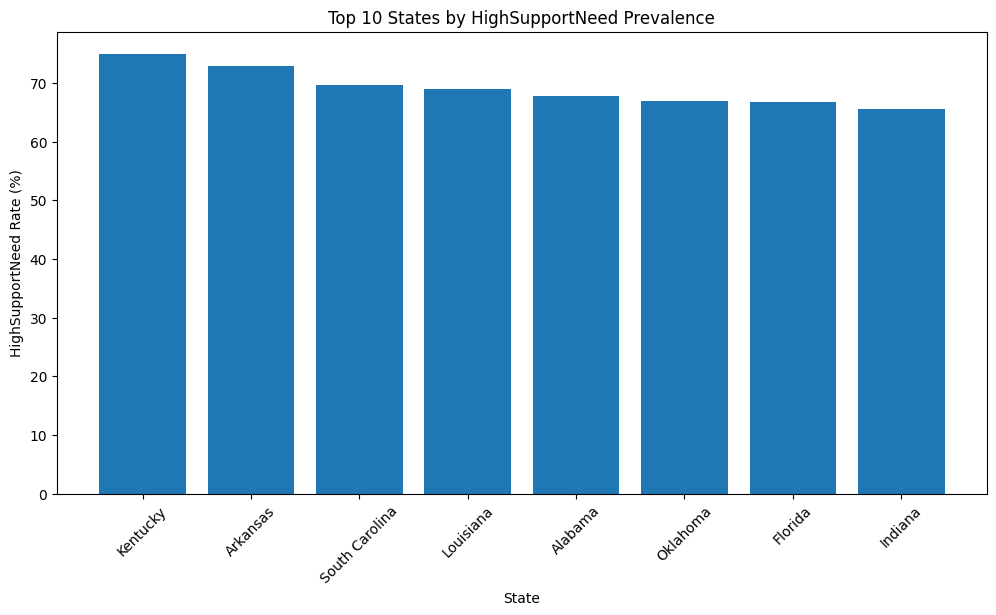

In [ ]:
# Top 10 States by HighSupportNeed Prevalence

import matplotlib.pyplot as plt

state_map = {
    72: "Puerto Rico",
    21: "Kentucky",
    54: "West Virginia",
    5: "Arkansas",
    22: "Louisiana",
    1: "Alabama",
    40: "Oklahoma",
    12: "Florida",
    45: "South Carolina",
    18: "Indiana"
}

top10_states = state_summary.head(10).copy()

# Map the index to state names, unmapped states will become NaN
# Create a temporary column for mapped names
top10_states['Mapped_State_Name'] = top10_states.index.astype(int).map(state_map)

# Filter out rows where the state name could not be mapped (resulting in NaN)
top10_states = top10_states.dropna(subset=['Mapped_State_Name'])

# Assign the cleaned mapped index to the DataFrame
top10_states.set_index('Mapped_State_Name', inplace=True)


plt.figure(figsize=(12,6))
plt.bar(top10_states.index, top10_states['HighNeedRate'])

plt.title("Top 10 States by HighSupportNeed Prevalence")
plt.xlabel("State")
plt.ylabel("HighSupportNeed Rate (%)")
plt.xticks(rotation=45)

plt.show()

## Interpretation

The chart displays the Top 10 states by HighSupportNeed prevalence, measured as the percentage of respondents classified as having high support needs. It compares states based on prevalence rather than raw counts, allowing a fair comparison across different state sizes. Puerto Rico shows the highest prevalence at approximately 80.9%, followed by Kentucky (75.0%) and West Virginia (73.6%), indicating relatively higher concentrations of individuals needing support services. Florida appears lower in prevalence at 66.8%, but it remains an important market because it also has a larger respondent base and higher total number of high-need individuals. Overall, the chart highlights clear variation in support needs across states and helps identify strong candidates for business expansion.

## Task 6: State-Level Analysis

We compared states using the percentage of HighSupportNeed instead of only total counts. The results showed clear differences across states. In top states, Cluster 0 was the most common group. Based on high need rate, number of respondents, and market size, Florida appears to be the best state for expansion.

Overall, this analysis demonstrates how demographic and socioeconomic factors can be used to identify high-need individuals and guide strategic healthcare expansion decisions.

## Business Recommendation

Based on the analysis, Florida emerges as the best state for expansion.

Florida combines a relatively high HighSupportNeed rate with the largest number of respondents and high total demand.

The presence of multiple clusters indicates diverse population segments requiring different types of healthcare support.

This makes Florida a strong candidate for launching home healthcare services.

## Limitations

This analysis is based on self-reported survey data, which may introduce bias.

The HighSupportNeed variable is a proxy and may not fully capture actual healthcare demand.

Additionally, missing data and survey limitations may affect results.

## Overall Project Conclusion

This project focused on identifying individuals who are most likely to require home healthcare support using demographic, socioeconomic, and health-related data from the BRFSS dataset. The primary objective was to support data-driven decision-making for healthcare service expansion.

In Phase 1, the dataset was cleaned by handling invalid survey responses and preparing variables for analysis. Key variables such as physical health, mental health, income, and chronic conditions were selected because they directly influence an individual’s ability to access and require healthcare support.

In Phase 2, a binary target variable, *HighSupportNeed*, was constructed to identify individuals likely to need additional support. Clustering analysis using K-Modes further segmented the population into meaningful groups based on demographic and socioeconomic characteristics. These clusters helped reveal different levels of risk and support needs across the population.

In Phase 3, a Random Forest classification model was developed to predict high-support individuals using non-leakage features. The model demonstrated moderate performance and showed that factors such as employment status, education level, marital status, and cluster membership are important predictors of healthcare support needs.

In Phase 4, a state-level analysis was conducted to identify regions with the highest demand for support services. By comparing both prevalence and population size, Florida was identified as the most suitable state for expansion due to its combination of high demand and large market size.

Overall, the project demonstrates how demographic, socioeconomic, and health indicators can be effectively combined to identify high-need populations and guide strategic healthcare decisions. The analysis highlights the importance of both individual-level risk factors and regional variations in planning targeted healthcare interventions.
